<a href="https://colab.research.google.com/github/JTSIV1/emotion-aware-s2st/blob/main/Translation%20LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 1: Load API key

In [1]:
!pip install -q openai transformers sacrebleu pandas
!apt-get install -q ffmpeg

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [2]:
from openai import OpenAI
import time, os, random, requests, tarfile, shutil, subprocess
from collections import defaultdict, Counter
from pathlib import Path
import pandas as pd

client = OpenAI(
    api_key="sk-741aba4dc4c64831a5680304db841dd4",
    base_url="https://llm.jetstream-cloud.org/api"
)

models = client.models.list()
for m in models.data:
    print(m.id)

llama-4-scout
DeepSeek-R1
gpt-oss-120b


In [3]:
MODEL_ID = "meta-llama/Llama-4-Scout-17B-16E-Instruct"
print(f"Using model: {MODEL_ID}")

Using model: meta-llama/Llama-4-Scout-17B-16E-Instruct


## Part 2: Load MELD-ST dataset

In [4]:

from IPython.display import display, Javascript

display(Javascript('''
    function ClickConnect(){
        console.log("Keeping alive...");
        document.querySelector("colab-toolbar-button#connect").click()
    }
    setInterval(ClickConnect, 60000)
'''))

<IPython.core.display.Javascript object>

In [5]:
MELD_URL        = "http://web.eecs.umich.edu/~mihalcea/downloads/MELD.Raw.tar.gz"
TEMP_TAR        = "MELD_Raw.tar.gz"
RAW_EXTRACT_DIR = "./temp_meld_extract"
DATA_DIR        = "./data"

def setup_directories(base_path):
    splits = ['train', 'dev', 'test']
    for split in splits:
        path = os.path.join(base_path, split)
        if not os.path.exists(path):
            os.makedirs(path)

def download_file(url, dest):
    print("downloading raw data...")
    response = requests.get(url, stream=True)
    with open(dest, 'wb') as f:
        for chunk in response.iter_content(chunk_size=1024*1024):
            if chunk:
                f.write(chunk)
    print("download complete")

setup_directories(DATA_DIR)
download_file(MELD_URL, TEMP_TAR)
print("Done.")

downloading raw data...
download complete
Done.


In [6]:
def process_and_cleanup(extract_path, final_data_path):
    meld_raw_dir = os.path.join(extract_path, "MELD.Raw")
    splits = ['train', 'dev', 'test']
    exported_name = {
        'train': "train_splits",
        'dev':   "dev_splits_complete",
        'test':  "output_repeated_splits_test"
    }

    for split in splits:
        inner_tar_name = f"{split}.tar.gz"
        inner_tar_path = os.path.join(meld_raw_dir, inner_tar_name)

        if not os.path.exists(inner_tar_path):
            print(f"{inner_tar_name} not found.")
            continue

        print(f"extracting {inner_tar_name}...")
        with tarfile.open(inner_tar_path, "r:gz") as tar:
            tar.extractall(path=meld_raw_dir)

        temp_video_folder = os.path.join(meld_raw_dir, exported_name[split])
        output_folder     = os.path.join(final_data_path, split)

        print(f"converting {split} clips to 16kHz audio...")
        if os.path.exists(temp_video_folder):
            for filename in os.listdir(temp_video_folder):
                if filename.endswith(".mp4"):
                    video_path = os.path.join(temp_video_folder, filename)
                    audio_path = os.path.join(output_folder, filename.replace(".mp4", ".wav"))
                    try:
                        subprocess.run([
                            'ffmpeg', '-y', '-i', video_path,
                            '-vn',
                            '-acodec', 'pcm_s16le',
                            '-ar', '16000',
                            '-ac', '1',
                            '-loglevel', 'error',
                            audio_path
                        ], check=True)
                        os.remove(video_path)
                    except Exception as e:
                        print(f"error processing {filename}: {e}")
            shutil.rmtree(temp_video_folder)

        os.remove(inner_tar_path)
        print(f"finished processing and cleaning up {split} set.")

    print("Moving CSV label files to ./data...")
    for csv_file in [f for f in os.listdir(meld_raw_dir) if f.endswith('.csv')]:
        shutil.move(
            os.path.join(meld_raw_dir, csv_file),
            os.path.join(final_data_path, csv_file)
        )

print("extracting data...")
with tarfile.open(TEMP_TAR, "r:gz") as tar:
    tar.extractall(path=RAW_EXTRACT_DIR)
os.remove(TEMP_TAR)

process_and_cleanup(RAW_EXTRACT_DIR, DATA_DIR)

print("cleanup...")
shutil.rmtree(RAW_EXTRACT_DIR)
print(f"done! data in {os.path.abspath(DATA_DIR)}")

extracting data...


/tmp/ipykernel_568811/2383539039.py:58: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=RAW_EXTRACT_DIR)


extracting train.tar.gz...


/tmp/ipykernel_568811/2383539039.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=meld_raw_dir)


converting train clips to 16kHz audio...
error processing dia125_utt3.mp4: Command '['ffmpeg', '-y', '-i', './temp_meld_extract/MELD.Raw/train_splits/dia125_utt3.mp4', '-vn', '-acodec', 'pcm_s16le', '-ar', '16000', '-ac', '1', '-loglevel', 'error', './data/train/dia125_utt3.wav']' returned non-zero exit status 1.
finished processing and cleaning up train set.
extracting dev.tar.gz...


/tmp/ipykernel_568811/2383539039.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=meld_raw_dir)


converting dev clips to 16kHz audio...
finished processing and cleaning up dev set.
extracting test.tar.gz...


/tmp/ipykernel_568811/2383539039.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=meld_raw_dir)


converting test clips to 16kHz audio...
error processing ._dia231_utt12.mp4: Command '['ffmpeg', '-y', '-i', './temp_meld_extract/MELD.Raw/output_repeated_splits_test/._dia231_utt12.mp4', '-vn', '-acodec', 'pcm_s16le', '-ar', '16000', '-ac', '1', '-loglevel', 'error', './data/test/._dia231_utt12.wav']' returned non-zero exit status 1.
error processing ._dia130_utt17.mp4: Command '['ffmpeg', '-y', '-i', './temp_meld_extract/MELD.Raw/output_repeated_splits_test/._dia130_utt17.mp4', '-vn', '-acodec', 'pcm_s16le', '-ar', '16000', '-ac', '1', '-loglevel', 'error', './data/test/._dia130_utt17.wav']' returned non-zero exit status 1.
error processing ._dia146_utt4.mp4: Command '['ffmpeg', '-y', '-i', './temp_meld_extract/MELD.Raw/output_repeated_splits_test/._dia146_utt4.mp4', '-vn', '-acodec', 'pcm_s16le', '-ar', '16000', '-ac', '1', '-loglevel', 'error', './data/test/._dia146_utt4.wav']' returned non-zero exit status 1.
error processing ._dia17_utt25.mp4: Command '['ffmpeg', '-y', '-i', './t

In [7]:
# Save processed data to Drive immediately after Cell 5 finishes
from google.colab import drive

# Mount only if not already mounted
if not os.path.exists("/content/drive"):
    drive.mount('/content/drive')

import shutil
if not os.path.exists("/content/drive/MyDrive/MELD_data"):
    shutil.copytree("./data", "/content/drive/MyDrive/MELD_data")
    print("Saved to Drive!")
else:
    print("Already saved to Drive, skipping.")

Already saved to Drive, skipping.


In [8]:
df_raw = pd.read_csv(os.path.join(DATA_DIR, "train_sent_emo.csv"))
print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
df_raw.head(5)

Shape: (9989, 11)

Columns: ['Sr No.', 'Utterance', 'Speaker', 'Emotion', 'Sentiment', 'Dialogue_ID', 'Utterance_ID', 'Season', 'Episode', 'StartTime', 'EndTime']


,Sr No.,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime
0,1,also I was the point person on my companys tr...,Chandler,neutral,neutral,0,0,8,21,"00:16:16,059","00:16:21,731"
1,2,You mustve had your hands full.,The Interviewer,neutral,neutral,0,1,8,21,"00:16:21,940","00:16:23,442"
2,3,That I did. That I did.,Chandler,neutral,neutral,0,2,8,21,"00:16:23,442","00:16:26,389"
3,4,So lets talk a little bit about your duties.,The Interviewer,neutral,neutral,0,3,8,21,"00:16:26,820","00:16:29,572"
4,5,My duties? All right.,Chandler,surprise,positive,0,4,8,21,"00:16:34,452","00:16:40,917"


In [10]:
# Check emotion labels
print("Raw emotion labels in train set:")
print(df_raw["Emotion"].value_counts())

Raw emotion labels in train set:
Emotion
neutral     4710
joy         1743
surprise    1205
anger       1109
sadness      683
disgust      271
fear         268
Name: count, dtype: int64


In [12]:
# Check sample utterances
print("Sample utterances per emotion:\n")
for emotion in df_raw["Emotion"].unique():
    sample = df_raw[df_raw["Emotion"] == emotion]["Utterance"].iloc[0]
    print(f"[{emotion:10s}] {sample}")

Sample utterances per emotion:

[neutral   ] also I was the point person on my companys transition from the KL-5 to GR-6 system.
[surprise  ] My duties?  All right.
[fear      ] No dont I beg of you!
[sadness   ] You know? Forget it!
[joy       ] Do I ever.
[disgust   ] Just coffee! Where are we gonna hang out now?
[anger     ] Oh no-no-no, give me some specifics.


## Part 3: Emotion mapping

In [13]:
EMOTIONS = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]
EMOTION_MAP = {e: e for e in EMOTIONS}

print("Emotions:", EMOTIONS)

Emotions: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']


In [14]:
def load_meld_split(split):
    csv_map = {
        "train": "train_sent_emo.csv",
        "dev":   "dev_sent_emo.csv",
        "test":  "test_sent_emo.csv",
    }
    de_csv_map = {
        "train": "deu_train.csv",
        "dev":   "deu_dev.csv",
        "test":  "deu_test.csv",
    }

    df = pd.read_csv(os.path.join(DATA_DIR, csv_map[split]))

    # Load DE references
    de_path = os.path.join(DATA_DIR, de_csv_map[split])
    de_lookup = {}
    if os.path.exists(de_path):
        df_de = pd.read_csv(de_path)
        for _, row in df_de.iterrows():
            key = f"{row['dia_id']}_{row['utt_id']}"
            de_lookup[key] = str(row.get("German", "")).strip()
        print(f"Loaded {len(de_lookup)} DE references for {split}")
    else:
        print(f"No DE reference found for {split} — BLEU will be N/A")

    data = []
    for _, row in df.iterrows():
        emotion = str(row.get("Emotion", "")).lower().strip()
        if emotion not in EMOTIONS:
            continue
        en_text = str(row.get("Utterance", "")).strip()
        if not en_text:
            continue
        utt_id = f"{row.get('Dialogue_ID', '')}_{row.get('Utterance_ID', '')}"
        data.append({
            "utterance_id": utt_id,
            "emotion":      emotion,
            "en_text":      en_text,
            "speaker":      str(row.get("Speaker", "")),
            "de_text":      de_lookup.get(utt_id, None),
        })
    return data

train_data = load_meld_split("train")
val_data   = load_meld_split("dev")
test_data  = load_meld_split("test")

print(f"\nTrain: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

No DE reference found for train — BLEU will be N/A
No DE reference found for dev — BLEU will be N/A
No DE reference found for test — BLEU will be N/A

Train: 9989 | Val: 1109 | Test: 2610


In [15]:
for split_name, split_data in [("Train", train_data), ("Val", val_data), ("Test", test_data)]:
    print(f"\n{split_name} emotion distribution:")
    for e, c in sorted(Counter(d["emotion"] for d in split_data).items()):
        print(f"  {e:10s}: {c}")


Train emotion distribution:
  anger     : 1109
  disgust   : 271
  fear      : 268
  joy       : 1743
  neutral   : 4710
  sadness   : 683
  surprise  : 1205

Val emotion distribution:
  anger     : 153
  disgust   : 22
  fear      : 40
  joy       : 163
  neutral   : 470
  sadness   : 111
  surprise  : 150

Test emotion distribution:
  anger     : 345
  disgust   : 68
  fear      : 50
  joy       : 402
  neutral   : 1256
  sadness   : 208
  surprise  : 281


In [16]:
print("Sample entries per emotion from test set:\n")
for emotion in sorted(set(d["emotion"] for d in test_data)):
    sample = next(d for d in test_data if d["emotion"] == emotion)
    print(f"[{emotion:10s}] {sample['en_text']}")

Sample entries per emotion from test set:

[anger     ] Oh. Thats so Monica can keep track. That way if one on them is missing, she can be like, Wheres number 27?!
[disgust   ] Ugh, can you believe that guy!
[fear      ] No wait, look. Look! I'm sorry, it's just I've never even
[joy       ] Push!
[neutral   ] Y'know what?
[sadness   ] Uhh, yes I did but there isn't. Okay, here we go.
[surprise  ] Why do all youre coffee mugs have numbers on the bottom?


In [17]:
import numpy as np

print("Average word count per emotion (test set):")
for emotion in sorted(set(d["emotion"] for d in test_data)):
    subset = [d for d in test_data if d["emotion"] == emotion]
    avg_len = np.mean([len(d["en_text"].split()) for d in subset])
    print(f"  {emotion:10s}: {avg_len:.1f} words  (n={len(subset)})")

Average word count per emotion (test set):
  anger     : 9.5 words  (n=345)
  disgust   : 10.8 words  (n=68)
  fear      : 11.6 words  (n=50)
  joy       : 7.5 words  (n=402)
  neutral   : 8.0 words  (n=1256)
  sadness   : 9.9 words  (n=208)
  surprise  : 6.0 words  (n=281)


In [18]:
speakers = set(d["speaker"] for d in train_data)
print(f"Unique speakers in train: {len(speakers)}")
print("Speakers:", sorted(speakers))

Unique speakers in train: 260
Speakers: ['1st Customer', '2nd Customer', '3rd Customer', 'A Female Student', 'A Student', 'Airline Employee', 'Alice', 'All', 'Allesandro', 'Angela', 'Annabelle', 'Another Scientist', 'Another Tour Guide', 'Aunt Lillian', 'Barry', 'Ben', 'Bernice', 'Bob', 'Bobby', 'Bonnie', 'Both', 'Boy in the Cape', 'Burt', 'Caitlin', 'Carl', 'Carol', 'Casey', 'Cassie', 'Cecilia', 'Chandler', 'Charlie', 'Charlton Heston', 'Chip', 'Chloe', 'Cliff', 'Commercial', 'Customer', 'Dana', 'Danny', 'David', 'Dina', 'Director', 'Doctor', 'Doug', 'Dr. Baldhara', 'Dr. Drake Remoray', 'Dr. Franzblau', 'Dr. Green', 'Dr. Johnson', 'Dr. Ledbetter', 'Dr. Leedbetter', 'Dr. Long', 'Dr. Miller', 'Dr. Oberman', 'Dr. Rhodes', 'Dr. Stryker Ramoray', 'Dr. Wesley', 'Dr. Zane', 'Drunken Gambler', 'Duncan', 'Earl', 'Elizabeth', 'Emeril', 'Emily', 'Eric', 'Estelle', 'Evil Bitch', 'Fake Monica', 'Fireman No. 1', 'Fireman No. 2', 'Fireman No. 3', 'Flight Attendant', 'Frank', 'Friend No. 1', 'Friend 

## Section 3: Translation EN to DE (German)

In [25]:
def translate(transcript: str, emotion: str, retries: int = 3) -> dict:
    """
    Input  (from ASR): English transcript + emotion label
    Output (to TTS):   {translated_text: German, emotion: str}
    """
    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model=MODEL_ID,
                messages=[
                    {"role": "system", "content": (
                        f"You are an expert English-to-German translator. "
                        f"The speaker's emotion is: {emotion}. "
                        f"Use vocabulary, punctuation, and expressions "
                        f"appropriate for a {emotion} speaker in German. "
                        f"Output only the German translation, nothing else."
                    )},
                    {"role": "user", "content": f'Translate: "{transcript}"'}
                ],
                temperature=0.3,
                max_tokens=256,
            )
            return {"translated_text": response.choices[0].message.content.strip(), "emotion": emotion}
        except Exception as e:
            print(f"Attempt {attempt+1} failed: {e}")
            if attempt < retries - 1:
                time.sleep(2)
    return {"translated_text": "", "emotion": emotion}

In [24]:
def translate_baseline(transcript: str, retries: int = 3) -> dict:
    """Plain translation with NO emotion conditioning."""
    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model=MODEL_ID,
                messages=[
                    {"role": "system", "content": (
                        "You are an expert English-to-German translator. "
                        "Output only the German translation, nothing else."
                    )},
                    {"role": "user", "content": f'Translate: "{transcript}"'}
                ],
                temperature=0.3,
                max_tokens=256,
            )
            return {"translated_text": response.choices[0].message.content.strip()}
        except Exception as e:
            print(f"Attempt {attempt+1} failed: {e}")
            if attempt < retries - 1:
                time.sleep(2)
    return {"translated_text": ""}

In [23]:
MODEL_ID = "llama-4-scout"
print(f"Using model: {MODEL_ID}")

Using model: llama-4-scout


In [26]:
# Sanity check
test_cases = [
    ("I can't believe you did that!",      "anger"),
    ("That is absolutely disgusting.",     "disgust"),
    ("I am so scared right now.",          "fear"),
    ("This is the best day ever!",         "joy"),
    ("Please close the door.",             "neutral"),
    ("I miss you so much.",                "sadness"),
    ("No way, that actually happened?",    "surprise"),
]

print("Sanity Check: EN→DE with emotion conditioning\n")
for en, emotion in test_cases:
    out = translate(en, emotion)
    print(f"[{emotion:10s}] EN: {en}")
    print(f"             DE: {out['translated_text']}\n")

Sanity Check: EN→DE with emotion conditioning

[anger     ] EN: I can't believe you did that!
             DE: "Ich kann nicht glauben, dass du das getan hast! Das ist unglaublich!"

[disgust   ] EN: That is absolutely disgusting.
             DE: Das ist absolut ekelhaft.

[fear      ] EN: I am so scared right now.
             DE: Ich habe so eine Angst gerade.

[joy       ] EN: This is the best day ever!
             DE: Das ist der beste Tag aller Zeiten!

[neutral   ] EN: Please close the door.
             DE: Bitte schließen Sie die Tür.

[sadness   ] EN: I miss you so much.
             DE: Ich vermisse dich so sehr...

[surprise  ] EN: No way, that actually happened?
             DE: Nein, das kann doch nicht wahr sein! Das ist ja unglaublich!



## Part 4: Sentiment classifier

In [27]:
from transformers import pipeline

sentiment_pipe = pipeline(
    "text-classification",
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    device=0,  # use -1 if no GPU
)

# neutral excluded — 3-class model can't reliably detect it
SENTIMENT_TO_EMOTIONS = {
    "positive": {"joy", "surprise"},
    "negative": {"anger", "disgust", "fear", "sadness"},
}

print("Sentiment classifier ready!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Sentiment classifier ready!


In [28]:
EMOTION_MARKERS = {
    "anger":    ["verdammt", "unglaublich", "wie kannst du", "schäm dich", "!"],
    "disgust":  ["ekelhaft", "widerlich", "abstoßend", "igitt", "pfui"],
    "fear":     ["angst", "fürchte", "erschrocken", "hilfe", "bitte nicht"],
    "joy":      ["wunderbar", "toll", "super", "fantastisch", "großartig", "hurra"],
    "neutral":  ["ich", "das", "ist", "und", "die", "der"],
    "sadness":  ["leider", "traurig", "schade", "es tut mir leid"],
    "surprise": ["unglaublich", "wirklich", "echt", "wow", "nicht möglich", "oh"],
}

print("German emotion markers defined:")
for e, markers in EMOTION_MARKERS.items():
    print(f"  {e:10s}: {markers}")

German emotion markers defined:
  anger     : ['verdammt', 'unglaublich', 'wie kannst du', 'schäm dich', '!']
  disgust   : ['ekelhaft', 'widerlich', 'abstoßend', 'igitt', 'pfui']
  fear      : ['angst', 'fürchte', 'erschrocken', 'hilfe', 'bitte nicht']
  joy       : ['wunderbar', 'toll', 'super', 'fantastisch', 'großartig', 'hurra']
  neutral   : ['ich', 'das', 'ist', 'und', 'die', 'der']
  sadness   : ['leider', 'traurig', 'schade', 'es tut mir leid']
  surprise  : ['unglaublich', 'wirklich', 'echt', 'wow', 'nicht möglich', 'oh']


In [29]:
# Quick check that the sentiment classifier works on German text
test_sentences = [
    ("Das ist verdammt nochmal unglaublich!",        "anger"),
    ("Das ist ekelhaft, ich kann das nicht ansehen.", "disgust"),
    ("Ich habe so eine Angst, bitte hilf mir.",       "fear"),
    ("Das ist wunderbar, ich bin so glücklich!",      "joy"),
    ("Bitte schließ die Tür.",                        "neutral"),
    ("Ich vermisse dich so sehr, es tut mir leid.",   "sadness"),
    ("Wow, das ist wirklich passiert?",               "surprise"),
]

print("=== Sentiment Classifier Test on German ===\n")
for text, expected in test_sentences:
    pred = sentiment_pipe(text[:512])[0]
    print(f"Text     : {text}")
    print(f"Expected : {expected}")
    print(f"Predicted: {pred['label']} (score: {pred['score']:.2f})\n")

=== Sentiment Classifier Test on German ===

Text     : Das ist verdammt nochmal unglaublich!
Expected : anger
Predicted: negative (score: 0.91)

Text     : Das ist ekelhaft, ich kann das nicht ansehen.
Expected : disgust
Predicted: negative (score: 0.71)

Text     : Ich habe so eine Angst, bitte hilf mir.
Expected : fear
Predicted: negative (score: 0.62)

Text     : Das ist wunderbar, ich bin so glücklich!
Expected : joy
Predicted: negative (score: 0.65)

Text     : Bitte schließ die Tür.
Expected : neutral
Predicted: negative (score: 0.70)

Text     : Ich vermisse dich so sehr, es tut mir leid.
Expected : sadness
Predicted: negative (score: 0.68)

Text     : Wow, das ist wirklich passiert?
Expected : surprise
Predicted: positive (score: 0.39)



In [40]:
# 20 per emotion = 140 items total (7 emotions × 20)
small_test = []
for emotion in sorted(set(d["emotion"] for d in test_data)):
    subset = [d for d in test_data if d["emotion"] == emotion][:20]
    small_test += subset

print(f"Small test set: {len(small_test)} items")
for e, c in sorted(Counter(d["emotion"] for d in small_test).items()):
    print(f"  {e:10s}: {c}")

Small test set: 140 items
  anger     : 20
  disgust   : 20
  fear      : 20
  joy       : 20
  neutral   : 20
  sadness   : 20
  surprise  : 20


## Part 5: Evaluation

In [41]:
def evaluate_emotion_conditioned(data):
    rows = []
    for emotion in sorted(set(d["emotion"] for d in data)):
        subset = [d for d in data if d["emotion"] == emotion]
        sent_correct, marker_count, sent_total = 0, 0, 0

        for item in subset:
            result = translate(item["en_text"], item["emotion"])
            de = result["translated_text"]
            if not de:
                continue

            if emotion != "neutral":
                pred     = sentiment_pipe(de[:512])[0]["label"].lower()
                expected = {k for k, v in SENTIMENT_TO_EMOTIONS.items() if emotion in v}
                sent_correct += int(pred in expected)
                sent_total   += 1

            marker_count += int(any(m in de.lower() for m in EMOTION_MARKERS[emotion]))

        rows.append({
            "Emotion":        emotion,
            "N":              len(subset),
            "Sentiment acc.": f"{sent_correct/sent_total:.1%}" if sent_total else "N/A",
            "Marker rate":    f"{marker_count/len(subset):.1%}",
        })

    df = pd.DataFrame(rows)
    print("\n=== Emotion-Conditioned Translation Results ===")
    print(df.to_string(index=False))
    return df

conditioned_df = evaluate_emotion_conditioned(small_test)


=== Emotion-Conditioned Translation Results ===
 Emotion  N Sentiment acc. Marker rate
   anger 20          50.0%      100.0%
 disgust 20          70.0%       15.0%
    fear 20          65.0%        5.0%
     joy 20          60.0%        0.0%
 neutral 20            N/A       60.0%
 sadness 20          70.0%       20.0%
surprise 20          40.0%       25.0%


In [48]:
def evaluate_emotion_conditioned(data):
    results = []
    for emotion in sorted(set(d["emotion"] for d in data)):
        subset = [d for d in data if d["emotion"] == emotion]
        sent_correct, marker_count, sent_total = 0, 0, 0

        for item in subset:
            result = translate(item["en_text"], item["emotion"])
            de = result["translated_text"]
            if not de:
                continue

            if emotion != "neutral":
                pred     = sentiment_pipe(de[:512])[0]["label"].lower()
                expected = {k for k, v in SENTIMENT_TO_EMOTIONS.items() if emotion in v}
                sent_correct += int(pred in expected)
                sent_total   += 1

            marker_count += int(any(m in de.lower() for m in EMOTION_MARKERS[emotion]))

        results.append({
            "emotion":    emotion,
            "n":          len(subset),
            "sent_acc":   sent_correct / sent_total if sent_total else None,
            "marker_rate": marker_count / len(subset),
        })
    return results

conditioned_results = evaluate_emotion_conditioned(small_test)
print("Done! Results collected.")

Done! Results collected.


In [49]:
import pandas as pd

rows = []
for r in conditioned_results:
    rows.append({
        "Emotion":        r["emotion"],
        "N":              r["n"],
        "Sentiment acc.": f"{r['sent_acc']:.1%}" if r["sent_acc"] is not None else "N/A",
        "Marker rate":    f"{r['marker_rate']:.1%}",
    })

conditioned_df = pd.DataFrame(rows)
print("\n=== Emotion-Conditioned Translation Results ===")
print(conditioned_df.to_string(index=False))


=== Emotion-Conditioned Translation Results ===
 Emotion  N Sentiment acc. Marker rate
   anger 20          55.0%       95.0%
 disgust 20          65.0%       15.0%
    fear 20          70.0%       10.0%
     joy 20          60.0%        0.0%
 neutral 20            N/A       60.0%
 sadness 20          70.0%       15.0%
surprise 20          40.0%       25.0%


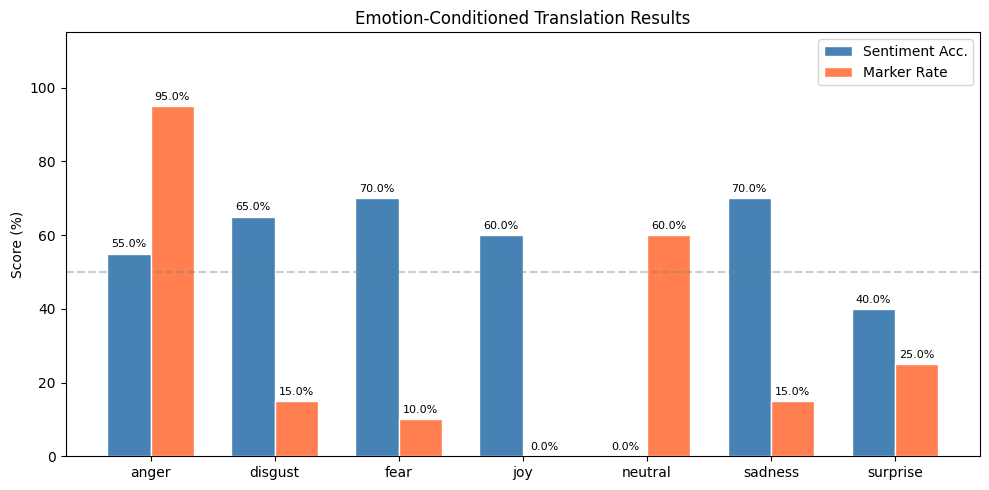

In [52]:
import matplotlib.pyplot as plt
import numpy as np

emotions    = [r["emotion"] for r in conditioned_results]
sent_vals   = [r["sent_acc"] * 100 if r["sent_acc"] is not None else 0 for r in conditioned_results]
marker_vals = [r["marker_rate"] * 100 for r in conditioned_results]

x     = np.arange(len(emotions))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, sent_vals,   width, label='Sentiment Acc.', color='steelblue', edgecolor='white')
b2 = ax.bar(x + width/2, marker_vals, width, label='Marker Rate',    color='coral',     edgecolor='white')
ax.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=8)
ax.set_title("Emotion-Conditioned Translation Results")
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 115)
ax.set_xticks(x)
ax.set_xticklabels(emotions)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig("./conditioned_results.png", dpi=150)
plt.show()

In [42]:
def full_comparison(data):
    rows = []
    for emotion in sorted(set(d["emotion"] for d in data)):
        subset = [d for d in data if d["emotion"] == emotion]
        base_sent, prompt_sent = 0, 0
        base_mark, prompt_mark = 0, 0
        sent_total, total = 0, 0

        for item in subset:
            base_de   = translate_baseline(item["en_text"])["translated_text"]
            prompt_de = translate(item["en_text"], item["emotion"])["translated_text"]
            if not base_de or not prompt_de:
                continue
            total += 1

            if emotion != "neutral":
                expected    = {k for k, v in SENTIMENT_TO_EMOTIONS.items() if emotion in v}
                base_pred   = sentiment_pipe(base_de[:512])[0]["label"].lower()
                prompt_pred = sentiment_pipe(prompt_de[:512])[0]["label"].lower()
                base_sent   += int(base_pred in expected)
                prompt_sent += int(prompt_pred in expected)
                sent_total  += 1

            base_mark   += int(any(m in base_de.lower()   for m in EMOTION_MARKERS[emotion]))
            prompt_mark += int(any(m in prompt_de.lower() for m in EMOTION_MARKERS[emotion]))

        rows.append({
            "Emotion":         emotion,
            "N":               total,
            "Base sent.":      f"{base_sent/sent_total:.1%}"   if sent_total else "N/A",
            "Prompted sent.":  f"{prompt_sent/sent_total:.1%}" if sent_total else "N/A",
            "Base marker":     f"{base_mark/total:.1%}",
            "Prompted marker": f"{prompt_mark/total:.1%}",
        })

    df = pd.DataFrame(rows)
    print("\n=== Baseline vs Emotion-Prompted (EN→DE) ===")
    print(df.to_string(index=False))
    print("\nHigher prompted scores = emotion conditioning is working.")
    return df

comparison_df = full_comparison(small_test)


=== Baseline vs Emotion-Prompted (EN→DE) ===
 Emotion  N Base sent. Prompted sent. Base marker Prompted marker
   anger 20      40.0%          50.0%       85.0%           95.0%
 disgust 20      55.0%          70.0%        0.0%           15.0%
    fear 20      55.0%          65.0%        0.0%           10.0%
     joy 20      75.0%          70.0%        0.0%            0.0%
 neutral 20        N/A            N/A       55.0%           60.0%
 sadness 20      65.0%          70.0%       15.0%           20.0%
surprise 20      40.0%          40.0%       25.0%           20.0%

Higher prompted scores = emotion conditioning is working.


In [43]:
# Generate DE pseudo-references for small_test and save
import json

CACHE_PATH = "./data/de_pseudo_references.json"

# Load cache if exists
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "r", encoding="utf-8") as f:
        de_cache = json.load(f)
    print(f"Loaded {len(de_cache)} cached DE references.")
else:
    de_cache = {}

# Generate for items not yet cached
for item in small_test:
    key = f"{item['utterance_id']}_{item['emotion']}"
    if key not in de_cache:
        result = translate(item["en_text"], item["emotion"])
        de_cache[key] = result["translated_text"]

# Save cache
with open(CACHE_PATH, "w", encoding="utf-8") as f:
    json.dump(de_cache, f, ensure_ascii=False)
print(f"Saved {len(de_cache)} DE references.")

# Attach to small_test
for item in small_test:
    key = f"{item['utterance_id']}_{item['emotion']}"
    item["de_text"] = de_cache.get(key, None)

print("DE references attached to small_test.")

Loaded 35 cached DE references.
Saved 140 DE references.
DE references attached to small_test.


In [44]:
import sacrebleu

def evaluate_bleu(data):
    subset_with_de = [d for d in data if d.get("de_text")]
    if not subset_with_de:
        print("No DE references available — skipping BLEU.")
        return

    by_emotion = defaultdict(lambda: {"hyps": [], "refs": []})
    for item in subset_with_de:
        result = translate(item["en_text"], item["emotion"])
        by_emotion[item["emotion"]]["hyps"].append(result["translated_text"])
        by_emotion[item["emotion"]]["refs"].append(item["de_text"])

    print("\n=== BLEU Scores per Emotion ===")
    all_hyps, all_refs = [], []
    for emotion in sorted(by_emotion):
        bleu = sacrebleu.corpus_bleu(
            by_emotion[emotion]["hyps"],
            [by_emotion[emotion]["refs"]]
        )
        print(f"  {emotion:10s}: BLEU = {bleu.score:.2f}")
        all_hyps += by_emotion[emotion]["hyps"]
        all_refs += by_emotion[emotion]["refs"]

    overall = sacrebleu.corpus_bleu(all_hyps, [all_refs])
    print(f"  {'Overall':10s}: BLEU = {overall.score:.2f}")

evaluate_bleu(small_test)


=== BLEU Scores per Emotion ===
  anger     : BLEU = 84.95
  disgust   : BLEU = 71.35
  fear      : BLEU = 76.88
  joy       : BLEU = 83.13
  neutral   : BLEU = 88.01
  sadness   : BLEU = 89.29
  surprise  : BLEU = 64.36
  Overall   : BLEU = 82.75


In [45]:
def evaluate_chrf(data):
    by_emotion = defaultdict(lambda: {"hyps": [], "refs": []})
    for item in data:
        result = translate(item["en_text"], item["emotion"])
        by_emotion[item["emotion"]]["hyps"].append(result["translated_text"])
        by_emotion[item["emotion"]]["refs"].append(item["de_text"])

    print("\n=== chrF Scores per Emotion ===")
    all_hyps, all_refs = [], []
    for emotion in sorted(by_emotion):
        chrf = sacrebleu.corpus_chrf(
            by_emotion[emotion]["hyps"],
            [by_emotion[emotion]["refs"]]
        )
        print(f"  {emotion:10s}: chrF = {chrf.score:.2f}")
        all_hyps += by_emotion[emotion]["hyps"]
        all_refs += by_emotion[emotion]["refs"]

    overall = sacrebleu.corpus_chrf(all_hyps, [all_refs])
    print(f"  {'Overall':10s}: chrF = {overall.score:.2f}")

evaluate_chrf(small_test)


=== chrF Scores per Emotion ===
  anger     : chrF = 83.84
  disgust   : chrF = 75.05
  fear      : chrF = 85.70
  joy       : chrF = 87.67
  neutral   : chrF = 93.25
  sadness   : chrF = 93.49
  surprise  : chrF = 94.37
  Overall   : chrF = 86.03


In [46]:
!pip install -q bert-score

from bert_score import score as bert_score

def evaluate_bertscore(data):
    """
    Compares emotion-prompted vs baseline translations semantically.
    Higher BERTScore = prompted output is more semantically rich/different.
    Uses multilingual BERT to handle German.
    """
    prompted_outputs, baseline_outputs = [], []

    for item in data:
        prompted = translate(item["en_text"], item["emotion"])["translated_text"]
        baseline = translate_baseline(item["en_text"])["translated_text"]
        if prompted and baseline:
            prompted_outputs.append(prompted)
            baseline_outputs.append(baseline)

    P, R, F1 = bert_score(
        prompted_outputs,
        baseline_outputs,
        lang="de",
        verbose=False
    )

    print("\n=== BERTScore: Emotion-Prompted vs Baseline ===")
    print(f"  Precision : {P.mean():.4f}")
    print(f"  Recall    : {R.mean():.4f}")
    print(f"  F1        : {F1.mean():.4f}")
    print("\nNote: Lower F1 = more difference between prompted and baseline")
    print("      which suggests emotion conditioning is changing the output.")

evaluate_bertscore(small_test)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.1 MB/s eta 0:00:00


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== BERTScore: Emotion-Prompted vs Baseline ===
  Precision : 0.9033
  Recall    : 0.9205
  F1        : 0.9114

Note: Lower F1 = more difference between prompted and baseline
      which suggests emotion conditioning is changing the output.


In [47]:
def evaluate_emotion_consistency(data, n_samples=5):
    """
    Translates same sentence across all 5 emotions.
    Checks if outputs are actually different — proves emotion conditioning works.
    """
    sample_sentences = [d["en_text"] for d in data[:n_samples]]
    emotions = ["angry", "happy", "neutral", "sad", "surprise"]

    print("=== Emotion Consistency Check ===")
    print("Same sentence translated with different emotion labels:\n")

    for sentence in sample_sentences:
        print(f"EN: {sentence}")
        translations = {}
        for emotion in emotions:
            de = translate(sentence, emotion)["translated_text"]
            translations[emotion] = de
            print(f"  [{emotion:8s}]: {de}")

        # Check uniqueness — are all 5 outputs different?
        unique = len(set(translations.values()))
        print(f"  → Unique translations: {unique}/5\n")

evaluate_emotion_consistency(small_test)

=== Emotion Consistency Check ===
Same sentence translated with different emotion labels:

EN: Oh. Thats so Monica can keep track. That way if one on them is missing, she can be like, Wheres number 27?!
  [angry   ]: "Oh. Damit kann Monica das auch noch überwachen. Damit sie, wenn eins davon fehlt, sagen kann: Wo ist Nummer 27?!"
  [happy   ]: "Ooh, damit kann Monica den Überblick behalten. Wenn dann mal einer fehlt, kann sie sagen: ‚Wo ist Nummer 27?!‘"
  [neutral ]: "Oh. Damit kann Monica den Überblick behalten. Auf diese Weise, wenn einer von ihnen fehlt, kann sie sagen: Wo ist Nummer 27?!"
  [sad     ]: "Oh. Damit kann Monica den Überblick behalten. Auf diese Weise, wenn einer von ihnen fehlt, kann sie sagen: Wo ist Nummer 27?!" 

könnte auch so übersetzt werden:

"Oh. Damit Monica weiß, wer alles da ist. Wenn dann einer fehlt, kann sie gleich sagen: Wo ist Nummer 27?!"

 oder 

"Oh. Damit Monica Buch führen kann. Wenn dann einer von ihnen fehlt, kann sie fragen: Wo is

In [51]:
def full_summary(data):
    rows = []
    for emotion in sorted(set(d["emotion"] for d in data)):
        subset = [d for d in data if d["emotion"] == emotion]
        sent_correct, marker_count = 0, 0
        sent_total = 0
        bleu_hyps, bleu_refs = [], []
        chrf_hyps, chrf_refs = [], []

        for item in subset:
            result = translate(item["en_text"], item["emotion"])
            de = result["translated_text"]
            if not de:
                continue

            # Sentiment
            if emotion != "neutral":
                pred     = sentiment_pipe(de[:512])[0]["label"].lower()
                expected = {k for k, v in SENTIMENT_TO_EMOTIONS.items() if emotion in v}
                sent_correct += int(pred in expected)
                sent_total   += 1

            # Marker
            marker_count += int(any(m in de.lower() for m in EMOTION_MARKERS[emotion]))

            # BLEU + chrF (if DE reference available)
            if "de_text" in item:
                bleu_hyps.append(de)
                bleu_refs.append(item["de_text"])
                chrf_hyps.append(de)
                chrf_refs.append(item["de_text"])

        bleu_score = sacrebleu.corpus_bleu(bleu_hyps, [bleu_refs]).score if bleu_hyps else None
        chrf_score = sacrebleu.corpus_chrf(chrf_hyps, [chrf_refs]).score if chrf_hyps else None

        rows.append({
            "Emotion":        emotion,
            "N":              len(subset),
            "Sentiment acc.": f"{sent_correct/sent_total:.1%}" if sent_total else "N/A",
            "Marker rate":    f"{marker_count/len(subset):.1%}",
            "BLEU":           f"{bleu_score:.1f}" if bleu_score is not None else "N/A",
            "chrF":           f"{chrf_score:.1f}" if chrf_score is not None else "N/A",
        })

    df = pd.DataFrame(rows)
    print("\n=== Full Evaluation Summary ===")
    print(df.to_string(index=False))
    return df

summary_df = full_summary(small_test)


=== Full Evaluation Summary ===
 Emotion  N Sentiment acc. Marker rate BLEU chrF
   anger 20          55.0%       95.0% 82.1 88.0
 disgust 20          70.0%       10.0% 70.9 77.4
    fear 20          65.0%        5.0% 80.4 85.8
     joy 20          60.0%        0.0% 74.9 83.2
 neutral 20            N/A       60.0% 86.1 94.2
 sadness 20          70.0%       20.0% 85.4 91.7
surprise 20          40.0%       25.0% 77.3 92.2


In [55]:
import shutil, os
from google.colab import drive

if not os.path.exists("/content/drive"):
    drive.mount('/content/drive')

# Save processed data
if not os.path.exists("/content/drive/MyDrive/MELD_data"):
    shutil.copytree("./data", "/content/drive/MyDrive/MELD_data")
    print("Data saved to Drive!")
else:
    print("Data already in Drive.")

# Save result graphs
for f in ["conditioned_results.png", "comparison_results.png", "bleu_results.png", "chrf_results.png", "evaluation_results.png"]:
    if os.path.exists(f"./{f}"):
        shutil.copy(f"./{f}", f"/content/drive/MyDrive/{f}")
        print(f"Saved {f} to Drive.")

Data already in Drive.
Saved conditioned_results.png to Drive.


In [57]:
import json

notebook_path = "/content/drive/MyDrive/LLM_Speech_Tech.ipynb"  # adjust path

with open(notebook_path, "r") as f:
    nb = json.load(f)

# Remove problematic widget metadata
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open(notebook_path, "w") as f:
    json.dump(nb, f)

print("Fixed! Re-download and push to GitHub.")

Fixed! Re-download and push to GitHub.


In [58]:
import json

# Load your notebook — adjust filename
notebook_path = "/content/drive/MyDrive/LLM_Speech_Tech.ipynb"

with open(notebook_path, "r") as f:
    nb = json.load(f)

# Remove widget metadata from top level
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

# Remove widget metadata from each cell too
for cell in nb.get("cells", []):
    if "metadata" in cell:
        if "widgets" in cell["metadata"]:
            del cell["metadata"]["widgets"]
    # Clean output metadata
    for output in cell.get("outputs", []):
        if "metadata" in output:
            if "widgets" in output["metadata"]:
                del output["metadata"]["widgets"]

with open(notebook_path, "w") as f:
    json.dump(nb, f, indent=1)

print("Cleaned! Re-download and push.")

Cleaned! Re-download and push.
